# Prediksi Hipertensi - Deliverable Minggu 1

## 1. Load Data & Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../../health-dataset/hypertension_data.csv')

# Tampilkan beberapa baris pertama
print("Data Head:")
print(df.head())

# Tampilkan informasi dataset
print("\nData Info:")
df.info()

# Tampilkan statistik deskriptif
print("\nData Describe:")
print(df.describe(include='all'))

Data Head:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0  57.0  1.0   3       145   233    1        0      150      0      2.3   
1  64.0  0.0   2       130   250    0        1      187      0      3.5   
2  52.0  1.0   1       130   204    0        0      172      0      1.4   
3  56.0  0.0   1       120   236    0        1      178      0      0.8   
4  66.0  0.0   0       120   354    0        1      163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26083 entries, 0 to 26082
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       26083 non-null  float64
 1   sex       26058 non-null  float64
 2   cp        26083 non-null  int64  
 3   trestbps  26083 non-null  int64  
 4   chol

## 2. Exploratory Data Analysis (EDA)

### 2.1. Cek Missing Values

In [2]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
sex         25
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
dtype: int64


### 2.2. Distribusi Fitur Numerik

Numerical Features for Distribution Plot: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


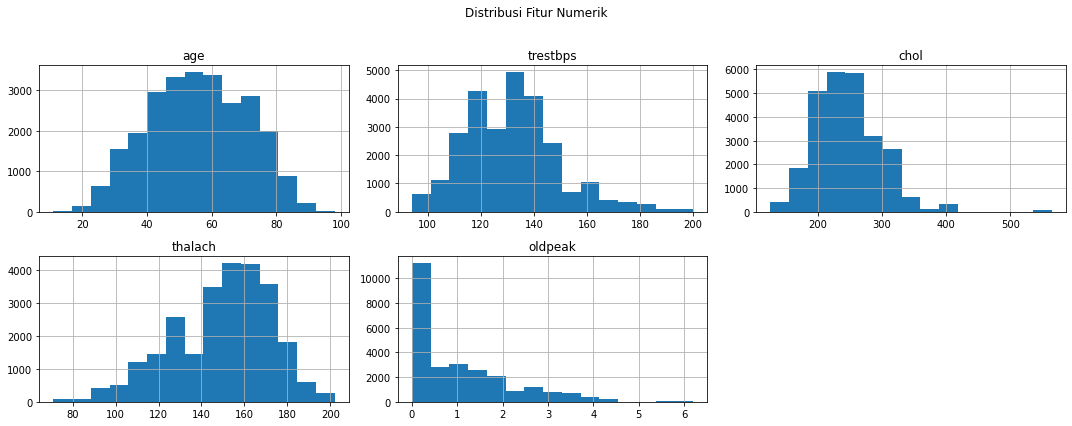

In [3]:
# Explicitly define numerical and categorical features based on dataset description
# Target column is 'target'
target_col_name = 'target'

explicit_numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
explicit_categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Ensure all defined columns exist in the dataframe, warn if not
actual_cols = df.columns.tolist()
for col_list_name, col_list in zip(['explicit_numerical_cols', 'explicit_categorical_cols'], [explicit_numerical_cols, explicit_categorical_cols]):
    for col in col_list:
        if col not in actual_cols:
            print(f"Warning: Column '{col}' defined in '{col_list_name}' not found in DataFrame columns.")

# Filter to existing columns to avoid errors if a defined column is missing
plot_numerical_features = [col for col in explicit_numerical_cols if col in actual_cols]

print(f"Numerical Features for Distribution Plot: {plot_numerical_features}")

if plot_numerical_features:
    df[plot_numerical_features].hist(bins=15, figsize=(15, 6), layout=(2, 3))
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
plt.show()

### 2.3. Distribusi Fitur Kategorikal

Categorical Features for Distribution Plot: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


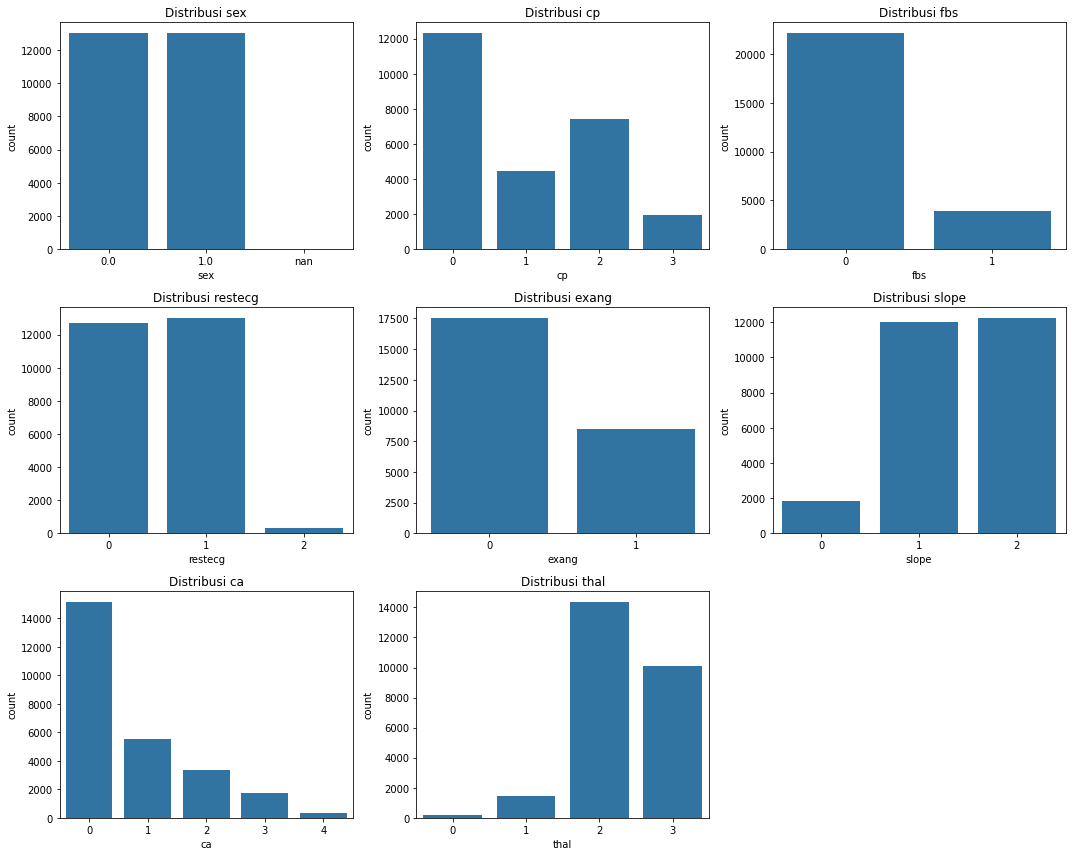

In [4]:
# Use explicitly defined categorical columns
plot_categorical_features = [col for col in explicit_categorical_cols if col in actual_cols]

print(f"Categorical Features for Distribution Plot: {plot_categorical_features}")

if plot_categorical_features:
    # Determine layout dynamically
    n_cols_plot = 3
    n_rows_plot = (len(plot_categorical_features) + n_cols_plot - 1) // n_cols_plot
    plt.figure(figsize=(15, n_rows_plot * 4))
    for i, col in enumerate(plot_categorical_features):
        plt.subplot(n_rows_plot, n_cols_plot, i + 1)
        # Check if column is actually object type for countplot, otherwise treat as discrete numeric
        if df[col].dtype == 'object':
            sns.countplot(data=df, y=col, order = df[col].value_counts().index)
        else: # For numerically encoded categoricals
            sns.countplot(data=df, x=col, order = sorted(df[col].unique()))
        plt.title(f'Distribusi {col}')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada fitur kategorikal (selain target) yang valid untuk diplot.")

#### 2.3.1. Cek Distribusi Nilai Fitur `thal` (Sebelum Imputasi Potensial)

In [5]:
print("Distribusi nilai untuk fitur 'thal':")
print(df['thal'].value_counts(normalize=True, dropna=False) * 100)

Distribusi nilai untuk fitur 'thal':
thal
2    55.051183
3    38.707204
1     5.651190
0     0.590423
Name: proportion, dtype: float64


### 2.4. Distribusi Target Variable


Distribusi Target Variable (target):
target
1    54.7253
0    45.2747
Name: proportion, dtype: float64


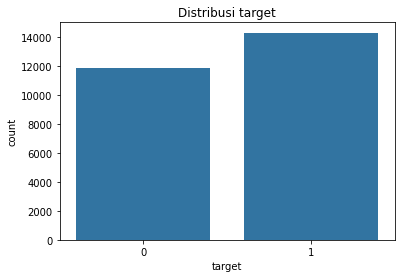

In [6]:
# target_col_name is already defined as 'target'
if target_col_name in df.columns:
    print(f"\nDistribusi Target Variable ({target_col_name}):")
    print(df[target_col_name].value_counts(normalize=True) * 100)
    sns.countplot(x=target_col_name, data=df)
    plt.title(f'Distribusi {target_col_name}')
    plt.show()
else:
    print(f"Kolom target '{target_col_name}' tidak ditemukan di dataset.")

### 2.5. Korelasi Antar Fitur Numerik

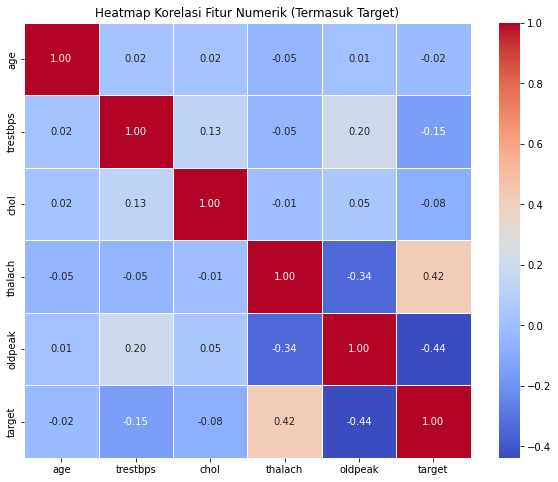

In [7]:
# Use explicitly defined numerical columns for correlation, and add the target
corr_features_for_heatmap = [col for col in explicit_numerical_cols if col in actual_cols]
if target_col_name in actual_cols and pd.api.types.is_numeric_dtype(df[target_col_name]):
    if target_col_name not in corr_features_for_heatmap:
        corr_features_for_heatmap.append(target_col_name)

if len(corr_features_for_heatmap) > 1: # Need at least two features for a meaningful correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[corr_features_for_heatmap].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Heatmap Korelasi Fitur Numerik (Termasuk Target)')
    plt.show()
else:
    print("Tidak cukup fitur numerik (termasuk target jika numerik) untuk membuat heatmap korelasi.")

### 2.6. Laporan Deskriptif (Ringkasan EDA)

Berdasarkan EDA yang telah dilakukan (menggunakan output yang disediakan):
- **Struktur Data**: Dataset `hypertension_data.csv` terdiri dari 26.083 baris dan 14 kolom. Kolom target adalah 'target'.
- **Missing Values**: Kolom `sex` memiliki 25 nilai yang hilang (missing values). Fitur lainnya tidak memiliki missing values. Imputasi akan dilakukan pada tahap preprocessing.
- **Tipe Data**: Sebagian besar fitur kategorikal (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`) direpresentasikan sebagai angka (float64 atau int64) dalam dataset, namun akan diperlakukan sebagai kategorikal sesuai deskripsi.
- **Distribusi Fitur Numerik**: 
  - `age`: Terdistribusi luas, dengan rentang dari 11 hingga 98 tahun, rata-rata sekitar 55.6 tahun.
  - `trestbps` (Resting Blood Pressure): Rata-rata 131.6 mm Hg, dengan beberapa nilai yang lebih tinggi.
  - `chol` (Cholesterol): Rata-rata 246.2 mg/dl, dengan sebaran yang cukup luas dan beberapa nilai tinggi.
  - `thalach` (Max Heart Rate): Rata-rata 149.7, terdistribusi mendekati normal.
  - `oldpeak` (ST Depression): Mayoritas nilai rendah (mendekati 0), dengan beberapa nilai yang lebih tinggi (right-skewed).
- **Distribusi Fitur Kategorikal** (berdasarkan nilai unik dan deskripsi dataset):
  - `sex`: 0 (female) dan 1 (male), hampir seimbang (sekitar 50% masing-masing setelah imputasi).
  - `cp` (Chest Pain Type): Terdapat 4 tipe (0-3), dengan tipe 0 (asymptomatic) paling umum.
  - `fbs` (Fasting Blood Sugar > 120 mg/dl): Mayoritas 0 (tidak), sekitar 15% bernilai 1 (ya).
  - `restecg` (Resting ECG): Terdapat 3 kategori (0, 1, 2).
  - `exang` (Exercise Induced Angina): Mayoritas 0 (tidak), sekitar 33% bernilai 1 (ya).
  - `slope` (Peak Exercise ST Segment Slope): Terdapat 3 kategori (0, 1, 2).
  - `ca` (Number of Major Vessels): Nilai dari 0 hingga 4 (nilai 4 mungkin perlu diperiksa, deskripsi menyebutkan 0-3).
  - `thal`: Nilai dari 0 hingga 3 (nilai 0 mungkin perlu diperiksa, deskripsi menyebutkan 3, 6, 7 yang mungkin di-map ke 0,1,2 atau 1,2,3).
- **Distribusi Target (`target`)**: Kelas cukup seimbang, dengan sekitar 54.7% pasien memiliki hipertensi (kelas 1) dan 45.3% tidak (kelas 0).
- **Korelasi**: (Akan diamati dari heatmap setelah notebook dijalankan. Berdasarkan output, korelasi antar fitur numerik dan target akan terlihat pada heatmap.)

## 3. Preprocessing & Feature Engineering

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Targeted imputation for 'thal' feature ---
# Based on EDA, 'thal' column has value 0 in ~0.59% of cases.
# We will impute these '0's with the dynamically calculated mode of the other 'thal' values.

# Calculate mode of 'thal' excluding 0
thal_values_for_mode = df.loc[df['thal'] != 0, 'thal']
if not thal_values_for_mode.empty:
    thal_mode_dynamic = thal_values_for_mode.mode()[0]
    print(f"Dynamically calculated mode for 'thal' (excluding 0): {thal_mode_dynamic}")
    df['thal'] = df['thal'].replace(0, thal_mode_dynamic)
    # print("\nValue counts for 'thal' after replacing 0s with dynamically calculated mode:") # This will be printed below
else:
    print("Warning: 'thal' column contains only 0s or is empty. No mode imputation performed for 0s.")

print("\nValue counts for 'thal' after potential imputation of 0s:")
print(df['thal'].value_counts(normalize=True, dropna=False) * 100)
# --- End of targeted imputation ---

# Define target variable and features using the correct target column name
target_variable_name = 'target'
X = df.drop(columns=[target_variable_name], errors='ignore') # Assuming 'id' is not present or already handled
if 'id' in X.columns: # Defensive check for 'id'
    X = X.drop(columns=['id'])
y = df[target_variable_name]

# Use explicitly defined numerical and categorical columns for preprocessing
# Filter them to ensure they exist in X to prevent errors
active_numerical_cols = [col for col in explicit_numerical_cols if col in X.columns]
active_categorical_cols = [col for col in explicit_categorical_cols if col in X.columns]

print(f"Numerical columns for preprocessing: {active_numerical_cols}")
print(f"Categorical columns for preprocessing: {active_categorical_cols}")

Dynamically calculated mode for 'thal' (excluding 0): 2

Value counts for 'thal' after potential imputation of 0s:
thal
2    55.641606
3    38.707204
1     5.651190
Name: proportion, dtype: float64
Numerical columns for preprocessing: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns for preprocessing: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


### 3.1. Create Preprocessing Pipelines

In [9]:
# Numerical pipeline: Impute with median, then scale
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create a column transformer to apply pipelines to respective columns
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, active_numerical_cols),
    ('categorical', categorical_pipeline, active_categorical_cols)
], remainder='passthrough') # Keep other columns (if any) unchanged

### 3.2. Data Splitting (Train-Validation-Test)

In [10]:
# Split data into training (70%) and temporary (30% for validation + test)
# Stratify by y to ensure proportional representation of classes
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split temporary data into validation (15% of total) and test (15% of total)
# This means validation and test will each be 50% of X_temp (0.15 / 0.30 = 0.5)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

print(f"\nProportion of target in y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nProportion of target in y_val:\n{y_val.value_counts(normalize=True)}")
print(f"\nProportion of target in y_test:\n{y_test.value_counts(normalize=True)}")

Shape of X_train: (18258, 13), y_train: (18258,)
Shape of X_val: (3912, 13), y_val: (3912,)
Shape of X_test: (3913, 13), y_test: (3913,)

Proportion of target in y_train:
target
1    0.547267
0    0.452733
Name: proportion, dtype: float64

Proportion of target in y_val:
target
1    0.54729
0    0.45271
Name: proportion, dtype: float64

Proportion of target in y_test:
target
1    0.547151
0    0.452849
Name: proportion, dtype: float64


### 3.3. Apply Preprocessing

In [11]:
# Fit the preprocessor on the training data and transform all sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding for better interpretability later
try:
    feature_names_out = preprocessor.get_feature_names_out()
except AttributeError:
    # For older scikit-learn versions, construct names manually or skip
    # This is a simplified way, might need adjustment based on actual transformers
    ohe_feature_names = []
    if active_categorical_cols: # Use active_categorical_cols
        try:
            ohe_feature_names = preprocessor.named_transformers_['categorical'].named_steps['onehot'].get_feature_names_out(active_categorical_cols).tolist()
        except AttributeError: # Fallback for older scikit-learn without get_feature_names_out on the step itself
            # This part might need more robust handling if scikit-learn version is very old
            # For now, assume it works or preprocessor.get_feature_names_out() is available
            pass 
    feature_names_out = active_numerical_cols + ohe_feature_names # Use active_numerical_cols

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names_out, index=X_val.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_out, index=X_test.index)

print("\nShape of X_train_processed_df:", X_train_processed_df.shape)
print("First 5 rows of X_train_processed_df:")
print(X_train_processed_df.head())


Shape of X_train_processed_df: (18258, 29)
First 5 rows of X_train_processed_df:
       numerical__age  numerical__trestbps  numerical__chol  \
25295        1.337436            -0.091622         0.192529   
18431       -1.029438             0.135219        -0.883078   
8122         1.008704             0.021798         1.874389   
17991       -1.292424             0.475480        -0.139931   
2077         0.679971            -1.679507         1.405033   

       numerical__thalach  numerical__oldpeak  categorical__sex_0.0  \
25295            0.013105           -0.892870                   1.0   
18431            0.362101           -0.203996                   0.0   
8122             0.711096            0.140440                   0.0   
17991            0.449349            0.140440                   0.0   
2077             0.449349           -0.892870                   0.0   

       categorical__sex_1.0  categorical__cp_0.0  categorical__cp_1.0  \
25295                   0.0            

## 4. Baseline Model (Logistic Regression)

Logistic Regression Baseline Model Evaluation on Validation Set:
AUC-ROC: 0.9270
Accuracy: 0.8704
Precision: 0.8488
Recall: 0.9285
F1-score: 0.8869

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1771
           1       0.85      0.93      0.89      2141

    accuracy                           0.87      3912
   macro avg       0.88      0.86      0.87      3912
weighted avg       0.87      0.87      0.87      3912


Confusion Matrix:


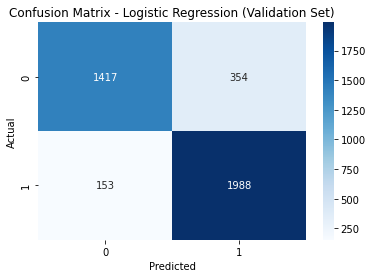

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train_processed_df, y_train)

# Make predictions on the validation set
y_val_pred_log_reg = log_reg_model.predict(X_val_processed_df)
y_val_pred_proba_log_reg = log_reg_model.predict_proba(X_val_processed_df)[:, 1]

# Evaluate the model
print("Logistic Regression Baseline Model Evaluation on Validation Set:")
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_pred_proba_log_reg):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_log_reg):.4f}")
print(f"F1-score: {f1_score(y_val, y_val_pred_log_reg):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_log_reg))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_log_reg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Validation Set)')
plt.show()

## 5. Save Artifacts for Week 2

In [13]:
import joblib
import os

# Define directory to save artifacts
output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

# Save the preprocessor
preprocessor_path = os.path.join(output_dir, 'preprocessor.joblib')
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to {preprocessor_path}")

# Save the processed data splits
# It's often better to save y as a Series to keep its name and index if needed
X_train_processed_df.to_csv(os.path.join(output_dir, 'X_train_processed.csv'))
X_val_processed_df.to_csv(os.path.join(output_dir, 'X_val_processed.csv'))
X_test_processed_df.to_csv(os.path.join(output_dir, 'X_test_processed.csv'))

y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), header=True)
y_val.to_csv(os.path.join(output_dir, 'y_val.csv'), header=True)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), header=True)

print(f"Processed data (X_train, X_val, X_test, y_train, y_val, y_test) saved to '{output_dir}' directory.")

Preprocessor saved to processed_data/preprocessor.joblib
Processed data (X_train, X_val, X_test, y_train, y_val, y_test) saved to 'processed_data' directory.
